In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.datasets import make_regression


In [9]:

# --- 1. Генерация данных с коррелированными признаками ---
# Создадим синтетический набор данных, который заставит Lasso
# проявлять эффект "случайного выбора" признаков,
# а Elastic-Net — эффект "группировки".
# N_samples (образцов) должно быть меньше N_features (признаков),
# чтобы подчеркнуть необходимость регуляризации.
N_SAMPLES = 100
N_FEATURES = 150
np.random.seed(42)


In [10]:

# Генерируем данные. Делаем их разреженными, чтобы Lasso работал эффективно.
# Добавляем высокую степень корреляции между признаками.
X, y = make_regression(n_samples=N_SAMPLES, n_features=N_FEATURES,
                       n_informative=10, n_targets=1,
                       noise=0.1, random_state=42)


In [11]:
# Дополнительно вводим сильную корреляцию между некоторыми признаками:
# Заставим признаки 0, 1 и 2 быть почти идентичными.
X[:, 0] = X[:, 1] + 0.01 * np.random.randn(N_SAMPLES)
X[:, 2] = X[:, 1] + 0.01 * np.random.randn(N_SAMPLES)


In [12]:
# Установим целевую ось для построения графиков
# Ось X будет представлять норму L1 вектора коэффициентов (для Lasso и Elastic-Net)
# Или параметр регуляризации alpha (для LassoLars)


In [13]:

# --- 2. Расчет траекторий коэффициентов (Coefficient Paths) ---


In [15]:

# 2.1. Lasso (Координатный спуск)
# Вычисляем путь Lasso. alphas - это последовательность значений регуляризации.
alphas_lasso, coefs_lasso, _ = linear_model.lasso_path(X, y, eps=1e-4, l1_ratio=1.0, fit_intercept=False)
# Примечание: l1_ratio=1.0 означает чистый Lasso [4]


TypeError: sklearn.linear_model._coordinate_descent.enet_path() got multiple values for keyword argument 'l1_ratio'

In [8]:

# 2.2. Elastic-Net
# l1_ratio < 1.0 дает Elastic-Net, использующий смесь L1 и L2 [2].
L1_RATIO_EN = 0.5
alphas_enet, coefs_enet, _ = linear_model.lasso_path(
    X, y, eps=1e-4, l1_ratio=L1_RATIO_EN, fit_intercept=False
)


TypeError: sklearn.linear_model._coordinate_descent.enet_path() got multiple values for keyword argument 'l1_ratio'

In [16]:

# 2.3. LARS Lasso
# LARS Lasso вычисляет точное решение [1]
# LARS генерирует "альфы" автоматически, поэтому мы используем его путь
alphas_lars_lasso, _, coefs_lars_lasso = linear_model.lars_path(
    X, y, method='lasso', verbose=False
)



In [17]:

# --- 3. Визуализация результатов с помощью Matplotlib ---

plt.figure(figsize=(15, 5))


<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

NameError: name 'alphas_lasso' is not defined

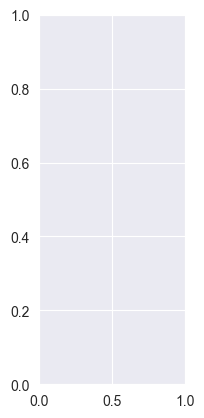

In [18]:
# -----------------
# 3.1. График Lasso
plt.subplot(1, 3, 1)
# Переворачиваем ось X, чтобы разреженность (высокий штраф) была слева
plt.plot(alphas_lasso, coefs_lasso.T)
plt.xlabel('$\\alpha$ (Lasso)')
plt.ylabel('Коэффициенты')
plt.title('Траектория Lasso (Координатный спуск)')
plt.axis('tight')

# Подчеркивание различий: Lasso имеет тенденцию обнулять коэффициенты (разреженность) [5].
# Обратите внимание, что когда альфа велика (слева), большинство коэффициентов равны нулю.


NameError: name 'alphas_enet' is not defined

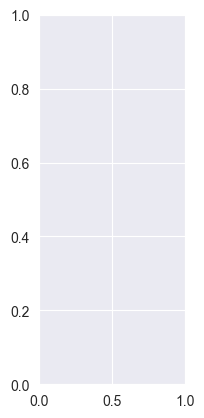

In [19]:

# -----------------
# 3.2. График Elastic-Net
plt.subplot(1, 3, 2)
plt.plot(alphas_enet, coefs_enet.T)
plt.xlabel('$\\alpha$ (Elastic-Net, $l_1/l_2=0.5$)')
plt.ylabel('Коэффициенты')
plt.title('Траектория Elastic-Net')
plt.axis('tight')

# Подчеркивание различий: Elastic-Net в отличие от чистого Lasso (который выбирает один случайный признак из группы коррелированных [3]),
# имеет тенденцию "группировать" коррелированные признаки (коэффициенты 0, 1, 2) и двигать их вместе.


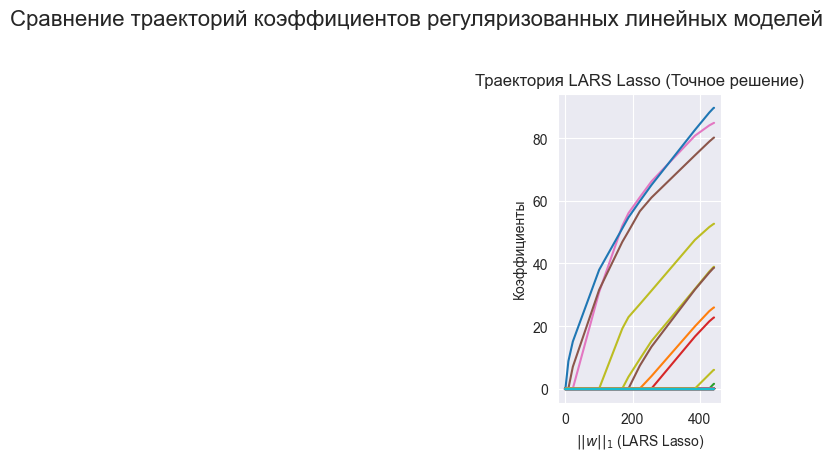

In [20]:
# -----------------
# 3.3. График LARS Lasso
plt.subplot(1, 3, 3)
# Для LARS Lasso ось X часто отображают как норму L1 вектора коэффициентов (sum of abs(coefs))
# lars_path возвращает coefs_path_ по l1-норме вектора w
xx = np.sum(np.abs(coefs_lars_lasso.T), axis=1)
plt.plot(xx, coefs_lars_lasso.T)
# Поскольку LARS Lasso дает кусочно-линейное решение [1], график выглядит более "ломаным"
plt.xlabel('$||w||_1$ (LARS Lasso)')
plt.ylabel('Коэффициенты')
plt.title('Траектория LARS Lasso (Точное решение)')
plt.axis('tight')

plt.suptitle('Сравнение траекторий коэффициентов регуляризованных линейных моделей', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()